In [3]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Load dataset from data folder
df = pd.read_csv("onego pipeline - pipeline.csv")

# Check first few rows of data
df.head()


,LEAD ID,NAME,PHONE NUMBER,COLLEGE,COURSES,LEAD SOURCE,STAGE,AMOUNT,FOLLOW - UP DATE,STATUS,CREATED DATE
0,100.0,PRAJAKTA,9.876543e+09,Mumbai University,Computer Science,INSTAGRAM,WON,8000.0,25-03-2026,OPENED,20-03-2026
1,101.0,ROHAN,9.876543e+09,Pune University,Data Science,INSTAGRAM,INTERESTED,10000.0,26-03-2026,CLOSED,21-03-2026
2,102.0,PRAJWAL,9.876543e+09,IIT Bombay,Mechanical Engineering,INSTAGRAM,LOST,12000.0,27-03-2026,OPENED,18-03-2026
3,103.0,SAKSHI,9.876543e+09,COEP,Civil Engineering,WEBSITE,NEW,9000.0,28-03-2026,OPENED,22-03-2026
4,104.0,AKSHDA,9.876543e+09,VIT Pune,Information Technology,REFERRAL,NEGOTIATION,18000.0,29-03-2026,CLOSED,19-03-2026


In [5]:
# Load dataset from data folder
df1 = pd.read_csv("invoice aging report - Sheet1.csv")

In [6]:
# Clean missing values

df1.head()

,INVOICE ID,CUSTOMER NAME,INVOICE DATE,DUE DATE,AMOUNT,PAYMENT STATUS,DAY PENDING,AGING BUCKET
0,1.0,PRAJAKTA,1/25/2026,2/9/2026,13320.0,Unpaid,42.0,31-60 Days
1,2.0,ROHAN,1/19/2026,2/3/2026,6974.0,Unpaid,48.0,31-60 Days
2,3.0,PRAJWAL,2/25/2026,3/12/2026,14160.0,Paid,0.0,0-15 Days
3,4.0,SAKSHI,2/16/2026,3/3/2026,17588.0,Paid,0.0,0-15 Days
4,5.0,AKSHDA,1/29/2026,2/13/2026,12085.0,Unpaid,38.0,31-60 Days


In [7]:
total_leads = len(df)

In [8]:
total_leads

102

In [9]:
open_leads = df[df['STATUS']=="OPENED"].shape[0]

In [10]:
open_leads

53

In [11]:
total_revenue = df['AMOUNT'].sum()

In [12]:
total_revenue

np.float64(9808458.0)

In [13]:
won_revenue = df[df['STAGE']=="Won"]['AMOUNT'].sum()

In [14]:
won_revenue

np.float64(0.0)

In [17]:
weekly_leads = df[df['CREATED DATE'] >= "2026-03-18"].shape[0]
weekly_leads

53

In [18]:
unpaid = df1[df1['PAYMENT STATUS']=="Unpaid"]['AMOUNT'].sum()

In [19]:
unpaid

np.float64(1313050.0)

In [20]:
overdue = df1[df1['DAY PENDING']>30].shape[0]

In [21]:
overdue

59

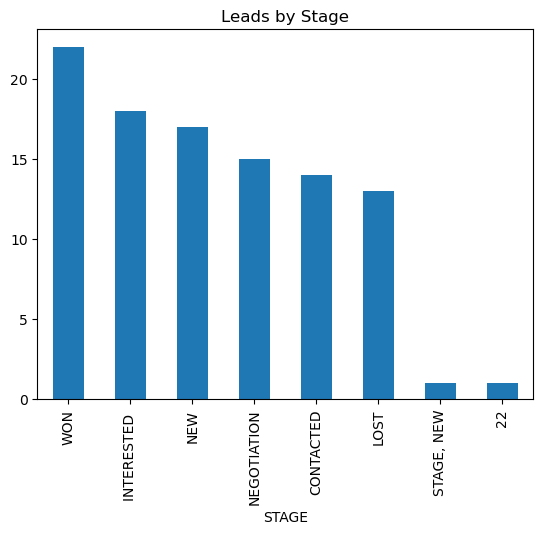

In [22]:
#create chart
df['STAGE'].value_counts().plot(kind='bar')
plt.title("Leads by Stage")
plt.show()

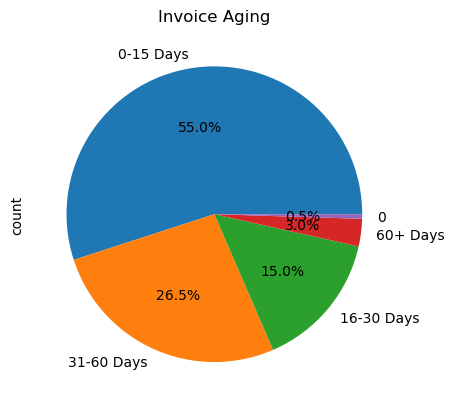

In [23]:
#AGING BUCKET

df1['AGING BUCKET'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Invoice Aging")
plt.show()

In [24]:
#summary


print("CEO Weekly Report")
print("------------------")
print("Total Leads:", total_leads)
print("Open Leads:", open_leads)
print("Revenue:", total_revenue)
print("Won Revenue:", won_revenue)
print("Unpaid Amount:", unpaid)
print("Overdue Invoices:", overdue)

CEO Weekly Report
------------------
Total Leads: 102
Open Leads: 53
Revenue: 9808458.0
Won Revenue: 0.0
Unpaid Amount: 1313050.0
Overdue Invoices: 59


In [29]:
# Convert date column to datetime format
df['CREATED DATE'] = pd.to_datetime(df['CREATED DATE'], format='mixed', dayfirst=True)

In [30]:
new_users = df[df['CREATED DATE'] >= pd.Timestamp.today() - pd.Timedelta(days=7)].shape[0]

In [31]:
new_users

5

In [32]:
df['CREATED DATE'].head()

0   2026-03-20
1   2026-03-21
2   2026-03-18
3   2026-03-22
4   2026-03-19
Name: CREATED DATE, dtype: datetime64[ns]

In [33]:
#calculate activated_user
activated_users = df[df['STAGE'].isin(['Interested','Negotiation','Won'])].shape[0]

In [34]:
activated_users

0

In [35]:
#calculate weekly active user
wau = df[df['CREATED DATE'] >= pd.Timestamp.today() - pd.Timedelta(days=7)].shape[0]

In [36]:
wau

5

In [37]:
#calculate retention rate
retention_rate = wau / len(df)

In [38]:
retention_rate

0.049019607843137254

In [39]:
placed = df[df['STAGE']=="Won"].shape[0]

In [40]:
placed 

0

In [41]:
revenue_week = df[df['CREATED DATE'] >= pd.Timestamp.today() - pd.Timedelta(days=7)]['AMOUNT'].sum()

In [42]:
revenue_week

np.float64(57000.0)

In [43]:
revenue_week

np.float64(57000.0)

In [47]:
unpaid = df1[df1['PAYMENT STATUS']=="Unpaid"]['AMOUNT'].sum()

In [48]:
unpaid

np.float64(1313050.0)